In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

In [4]:
model = tf.keras.models.load_model('/content/drive/MyDrive/best_coin_model.keras')

DATASET_PATH = '/content/drive/MyDrive/coins_dataset'

class_names = sorted([
    c for c in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, c))
    and not c.startswith('.')
])

print("Classes     :", class_names)
print("Class count :", len(class_names))
print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)

Classes     : ['10_rupee', '1_rupee', '2_rupee', '5_rupee']
Class count : 4
Input shape : (None, 256, 256, 3)
Output shape: (None, 4)


In [5]:
def nms_circles(circles, overlap_thresh=0.5):
    """
    Remove duplicate circles of the same coin.
    Keeps the largest circle when two overlap significantly.
    """
    if len(circles) == 0:
        return []

    circles = sorted(circles, key=lambda c: c[2], reverse=True)

    kept = []
    for (x1, y1, r1) in circles:
        duplicate = False
        for (x2, y2, r2) in kept:
            dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
            if dist < r2 * overlap_thresh:
                duplicate = True
                break
        if not duplicate:
            kept.append((x1, y1, r1))

    return kept


def detect_coins(image_path):
    img  = cv2.imread(image_path)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (15, 15), 3)

    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,
        dp=1.5,
        minDist=200,
        param1=80,
        param2=70,
        minRadius=180,
        maxRadius=350
    )

    if circles is None:
        print("No coins detected")
        return img, []

    circles = np.round(circles[0, :]).astype(int)
    print(f"Raw detections       : {len(circles)}")

    # Drop circles whose edge goes outside the frame
    valid = [
        (x, y, r) for (x, y, r) in circles
        if (x-r) >= 10 and (y-r) >= 10
        and (x+r) <= (w-10) and (y+r) <= (h-10)
    ]
    print(f"After boundary filter: {len(valid)}")

    # Remove overlapping duplicates
    final = nms_circles(valid, overlap_thresh=0.5)
    print(f"After NMS            : {len(final)}")

    return img, final


def crop_coin(img, x, y, r, padding=10):
    h, w = img.shape[:2]
    x1 = max(x - r - padding, 0)
    y1 = max(y - r - padding, 0)
    x2 = min(x + r + padding, w)
    y2 = min(y + r + padding, h)
    return img[y1:y2, x1:x2]

In [6]:
def add_black_background(cropped, r, shrink=5):
    """
    Masks everything outside the coin circle with pure black.
    shrink: trims the radius to cut off gray edge bleed.
    """
    h, w = cropped.shape[:2]
    cx, cy = w // 2, h // 2

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (cx, cy), max(r - shrink, 1), 255, thickness=-1)

    result = np.zeros_like(cropped)           # black canvas
    result[mask == 255] = cropped[mask == 255]
    return result

In [7]:
def preprocess_for_model(black_coin, input_size=(256, 256)):
    """
    EfficientNetB0 expects 256x256 and its own preprocess_input
    which scales [0,255] → [-1, 1] internally.
    """
    resized      = cv2.resize(black_coin, input_size).astype('float32')
    preprocessed = tf.keras.applications.efficientnet.preprocess_input(resized)
    return np.expand_dims(preprocessed, axis=0)   # → (1, 256, 256, 3)

Raw detections       : 3
After boundary filter: 3
After NMS            : 3


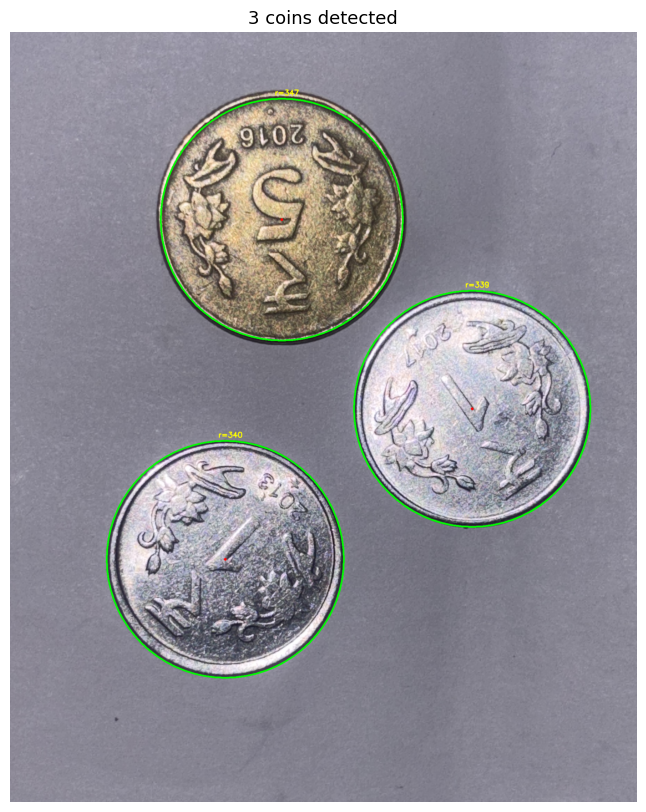

In [8]:
IMAGE_PATH = '/content/drive/MyDrive/IMG_6238.JPG'

img, circles = detect_coins(IMAGE_PATH)

debug_img = img.copy()
for (x, y, r) in circles:
    cv2.circle(debug_img, (x, y), r,  (0, 255, 0), 3)
    cv2.circle(debug_img, (x, y), 4,  (255, 0, 0), -1)
    cv2.putText(debug_img, f'r={r}', (x - 20, y - r - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

plt.figure(figsize=(12, 10))
plt.imshow(debug_img)
plt.title(f'{len(circles)} coins detected', fontsize=13)
plt.axis('off')
plt.show()

Raw detections       : 3
After boundary filter: 3
After NMS            : 3


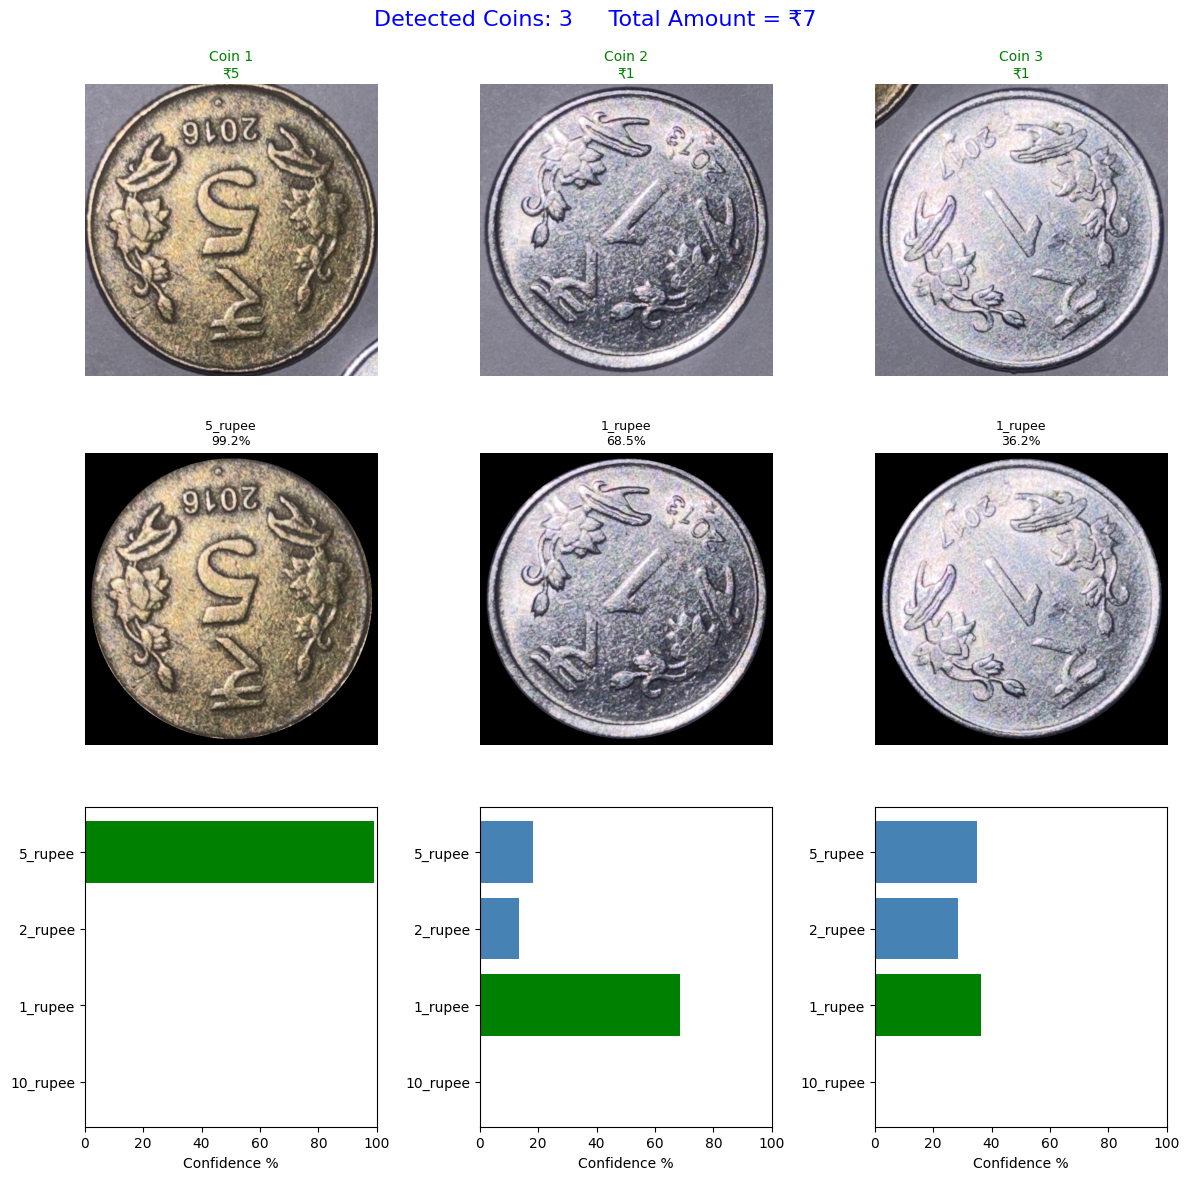

Detected Coins : 3
Total Amount   : ₹7


In [9]:
img, circles = detect_coins(IMAGE_PATH)

if len(circles) == 0:
    print("No coins detected — adjust HoughCircles params in Cell 4.")

else:
    n = len(circles)

    # Convert class name to value
    coin_value = {
        "1_rupee": 1,
        "2_rupee": 2,
        "5_rupee": 5,
        "10_rupee": 10
    }

    total_amount = 0

    fig, axes = plt.subplots(3, n, figsize=(4*n, 12))

    if n == 1:
        axes = axes.reshape(-1, 1)

    for i, (x, y, r) in enumerate(circles):

        cropped = crop_coin(img, x, y, r)
        black_coin = add_black_background(cropped, r, shrink=5)

        # Predict
        inp = preprocess_for_model(black_coin)
        pred = model.predict(inp, verbose=0)[0][:len(class_names)]

        label = class_names[np.argmax(pred)]
        confidence = np.max(pred) * 100

        value = coin_value[label]
        total_amount += value

        # ---------------- Row 1 ----------------
        axes[0, i].imshow(cropped)
        axes[0, i].axis("off")
        axes[0, i].set_title(
            f"Coin {i+1}\n₹{value}",
            fontsize=10,
            color="green"
        )

        # ---------------- Row 2 ----------------
        axes[1, i].imshow(black_coin)
        axes[1, i].axis("off")
        axes[1, i].set_title(
            f"{label}\n{confidence:.1f}%",
            fontsize=9
        )

        # ---------------- Row 3 ----------------
        colors = ["steelblue"] * len(class_names)
        colors[np.argmax(pred)] = "green"

        axes[2, i].barh(class_names, pred*100, color=colors)
        axes[2, i].set_xlim(0,100)
        axes[2, i].set_xlabel("Confidence %")

    plt.suptitle(
        f"Detected Coins: {n}     Total Amount = ₹{total_amount}",
        fontsize=16,
        color="blue"
    )

    plt.tight_layout()
    plt.show()

    print("="*40)
    print(f"Detected Coins : {n}")
    print(f"Total Amount   : ₹{total_amount}")
    print("="*40)

In [ ]:
print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)
print("Classes     :", class_names)
print()
model.summary()

Input shape : (None, 256, 256, 3)
Output shape: (None, 4)
Classes     : ['1_rupee', '2_rupee', '5_rupee']



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,143,857 (19.62 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 727,818 (2.78 MB)

In [ ]:
img, circles = detect_coins(IMAGE_PATH)

print("=" * 48)
print("   DETAILED CONFIDENCE SCORES")
print("=" * 48)

for i, (x, y, r) in enumerate(circles):
    cropped    = crop_coin(img, x, y, r)
    black_coin = add_black_background(cropped, r, shrink=5)

    inp  = preprocess_for_model(black_coin)
    pred = model.predict(inp, verbose=0)[0][:len(class_names)]

    print(f"\n  Coin {i+1}  (x={x}, y={y}, r={r})")
    for cls, score in sorted(zip(class_names, pred), key=lambda t: -t[1]):
        bar = '█' * int(score * 50)
        print(f"    {cls:<15} {score*100:5.1f}%  {bar}")

Raw detections       : 3
After boundary filter: 3
After NMS            : 3
   DETAILED CONFIDENCE SCORES

  Coin 1  (x=779, y=538, r=347)
    2_rupee          30.8%  ███████████████
    1_rupee          23.9%  ███████████
    5_rupee          23.4%  ███████████

  Coin 2  (x=617, y=1513, r=340)
    2_rupee          30.2%  ███████████████
    1_rupee          27.6%  █████████████
    5_rupee          17.8%  ████████

  Coin 3  (x=1325, y=1081, r=339)
    2_rupee          28.0%  █████████████
    1_rupee          26.1%  █████████████
    5_rupee          22.7%  ███████████
